<a href="https://colab.research.google.com/github/radita00/PCVK_Ganjil2026/blob/main/Week5_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Radita Yoga Anugrah'
NIM  = '244107020099'

N     = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Radita Yoga Anugrah
NIM    : 244107020099 | N = 99
bins   : 64
clip   : 3.0
tile   : 5
L      : 2
WAKTU  : 2026-10-03 10:29:20 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 017c614f04a0f8d6


In [3]:
# ===== SETUP: mount Drive, import library, folder, fungsi bantu =====
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob

CONTOH = '/content/drive/MyDrive/PCVK/Images'                # citra contoh bersama
BASE   = '/content/drive/MyDrive/PCVK/Images/' + NIM         # citra KTM milik Anda

# Foto HP berukuran besar membuat perulangan Python sangat lambat.
# Semua citra diperkecil (sisi terpanjang = MAXSISI) dengan INTER_AREA.
# Bentuk histogram tidak berubah. Isi None bila ingin ukuran asli.
MAXSISI = 1000

def muat(path, gray=False):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError('Citra tidak ditemukan: ' + path)
    s = max(img.shape[:2])
    if MAXSISI and s > MAXSISI:
        f = MAXSISI / s
        img = cv.resize(img, None, fx=f, fy=f, interpolation=cv.INTER_AREA)
    return img

def potong(img, frac):
    """frac = (y0, y1, x0, x1) dalam proporsi 0-1 terhadap ukuran citra."""
    H, W = img.shape[:2]
    y0, y1, x0, x1 = frac
    return img[int(y0*H):int(y1*H), int(x0*W):int(x1*W)]

print('Folder contoh:', os.listdir(CONTOH)[:10])
print('Folder KTM   :', sorted(os.listdir(BASE)))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder contoh: ['244107020099']
Folder KTM   : ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']


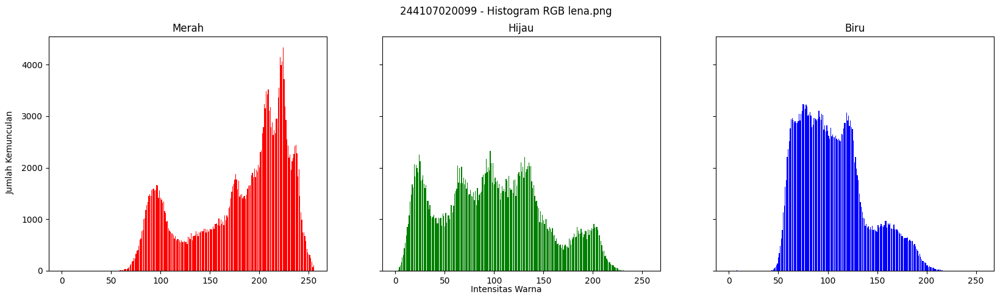

In [5]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def plot_rgb_manual(path, judul):
    bgr = muat(path)
    urut = [(2, 'Merah', 'red'), (1, 'Hijau', 'green'), (0, 'Biru', 'blue')]
    fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
    for ax, (i, nama, w) in zip(axs, urut):
        h = histogram_manual(bgr[:, :, i])
        assert h.sum() == bgr[:, :, i].size
        ax.bar(np.arange(256), h, color=w)
        ax.set_title(nama)
    fig.suptitle(NIM + ' - Histogram RGB ' + judul)
    fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
    fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
    plt.show()

# TAHAP 1 - citra contoh
plot_rgb_manual(CONTOH + '/lena.png', 'lena.png')

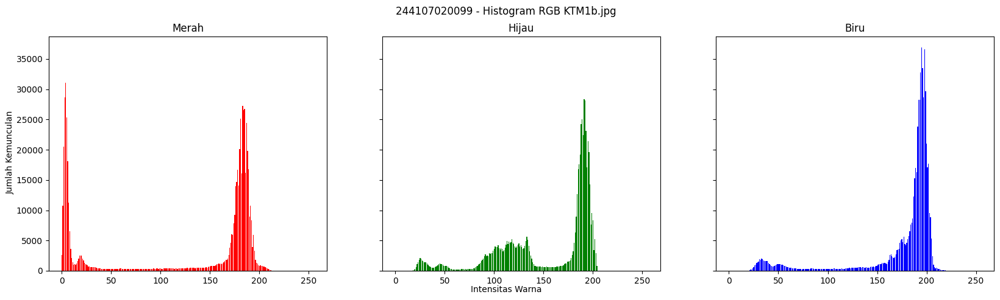

In [6]:
# TAHAP 2 - citra KTM sendiri
plot_rgb_manual(BASE + '/KTM1b.jpg', 'KTM1b.jpg')

In [10]:
def bandingkan_hist(path, tag):
    g  = muat(path, gray=True)
    h1 = histogram_manual(g)
    h2, _ = np.histogram(g, bins=256, range=(0, 256))
    h3 = cv.calcHist([g], [0], None, [256], [0, 256]).flatten().astype(np.int64)
    s12 = np.abs(h1 - h2).max()
    s13 = np.abs(h1 - h3).max()
    s23 = np.abs(h2 - h3).max()
    print(f'{NIM} - {tag}')
    print('  selisih maks manual vs np.histogram :', s12)
    print('  selisih maks manual vs cv.calcHist  :', s13)
    print('  selisih maks np.histogram vs calcHist:', s23)
    print('  BUKTI: semua nol ->', s12 == 0 and s13 == 0 and s23 == 0)

bandingkan_hist(CONTOH + '/lena.png', 'lena.png')
bandingkan_hist(BASE + '/KTM1b.jpg', 'KTM1b.jpg')

244107020099 - lena.png
  selisih maks manual vs np.histogram : 0
  selisih maks manual vs cv.calcHist  : 0
  selisih maks np.histogram vs calcHist: 0
  BUKTI: semua nol -> True
244107020099 - KTM1b.jpg
  selisih maks manual vs np.histogram : 0
  selisih maks manual vs cv.calcHist  : 0
  selisih maks np.histogram vs calcHist: 0
  BUKTI: semua nol -> True


Citra      rerata   median intensitas saat CDF=0.5
KTM1a       123.9    145.0                    145
KTM1b       147.8    182.0                    182
KTM1c       140.3    154.0                    154
KTM1d       154.5    191.0                    191


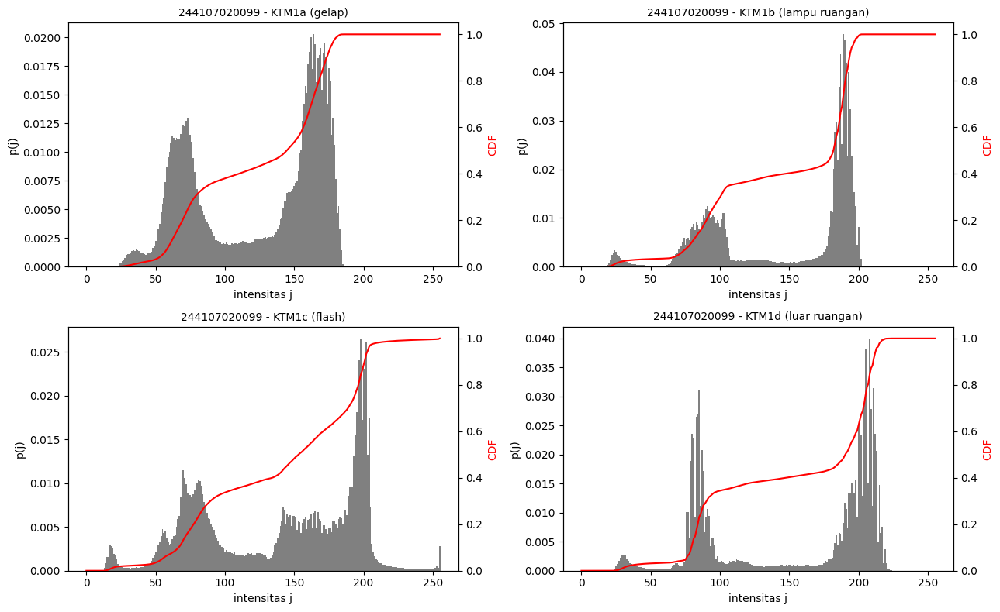

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
ket = {'a': 'gelap', 'b': 'lampu ruangan', 'c': 'flash', 'd': 'luar ruangan'}
print('%-8s %8s %8s %22s' % ('Citra', 'rerata', 'median', 'intensitas saat CDF=0.5'))
for ax, k in zip(axs.ravel(), 'abcd'):
    g   = muat(f'{BASE}/KTM1{k}.jpg', gray=True)
    h   = np.bincount(g.ravel(), minlength=256)
    p   = h / g.size                      # histogram ternormalisasi
    cdf = np.cumsum(p)                    # distribusi kumulatif
    ax.bar(np.arange(256), p, color='gray', width=1.0)
    ax.set_ylabel('p(j)')
    ax.set_xlabel('intensitas j')
    ax2 = ax.twinx()
    ax2.plot(cdf, color='red')
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('CDF', color='red')
    ax.set_title(f'{NIM} - KTM1{k} ({ket[k]})', fontsize=10)
    print('%-8s %8.1f %8.1f %22d' % ('KTM1' + k, g.mean(), np.median(g), np.searchsorted(cdf, 0.5)))
plt.tight_layout(); plt.show()

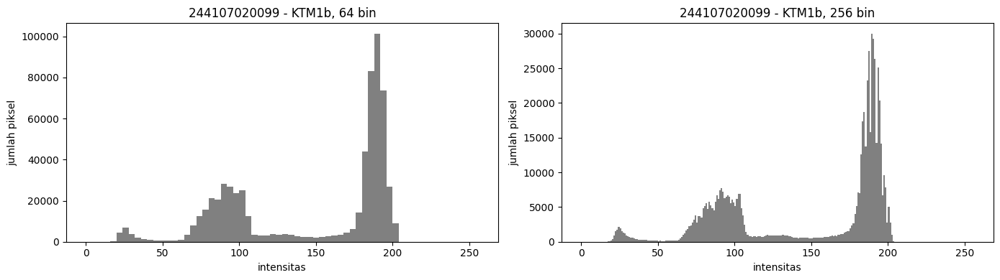

Tiap bin mewakili 4 level intensitas berdekatan.


In [12]:
g = muat(BASE + '/KTM1b.jpg', gray=True)
b = PARAM['bins']
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
axs[0].hist(g.ravel(), bins=b,   range=(0, 256), color='gray')
axs[0].set_title(f"{NIM} - KTM1b, {b} bin")
axs[1].hist(g.ravel(), bins=256, range=(0, 256), color='gray')
axs[1].set_title(f"{NIM} - KTM1b, 256 bin")
for ax in axs:
    ax.set_xlabel('intensitas'); ax.set_ylabel('jumlah piksel')
plt.tight_layout(); plt.show()
print('Tiap bin mewakili', 256 // b, 'level intensitas berdekatan.')

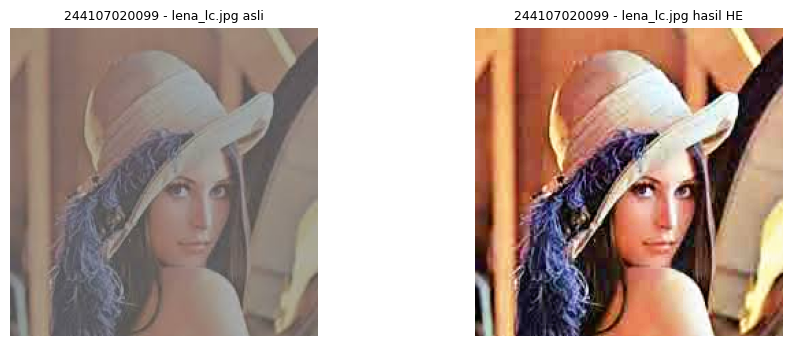

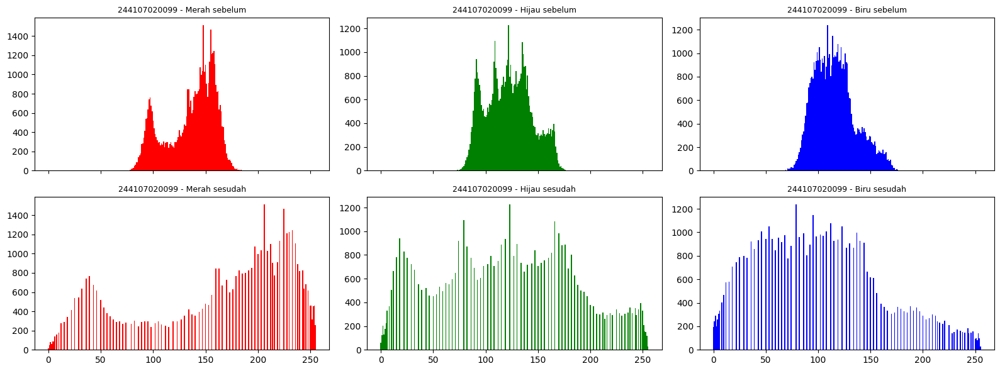

In [17]:
def he_manual(ch):
    """HE manual memakai rumus modul."""
    h   = np.bincount(ch.ravel(), minlength=256)    # frekuensi
    C   = np.cumsum(h)                               # kumulatif
    lut = np.round(C * 255 / ch.size).astype(np.uint8)
    return lut[ch]

def he_manual_cv(ch):
    """HE manual yang meniru OpenCV (kumulatif dikurangi nilai CDF terkecil)."""
    h    = np.bincount(ch.ravel(), minlength=256)
    C    = np.cumsum(h)
    cmin = C[C > 0].min()
    if ch.size == cmin:
        return ch.copy()
    scale = np.float32(255) / np.float32(ch.size - cmin)
    lut = np.round((C - cmin).astype(np.float32) * scale)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[ch]

def he_warna(bgr, fn=he_manual):
    return cv.merge([fn(bgr[:, :, i]) for i in range(3)])

def he_warna_gabungan(bgr):
    """Satu LUT dari histogram gabungan B+G+R, dipakai untuk ketiga kanal."""
    h   = sum(np.bincount(bgr[:, :, i].ravel(), minlength=256) for i in range(3))
    C   = np.cumsum(h)                                          # kumulatif
    lut = np.round(C * 255 / (bgr.shape[0] * bgr.shape[1] * 3)).astype(np.uint8)   # Ko
    return lut[bgr]

def tampil_he(bgr, he, judul):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    for ax, im, t in zip(axs, [bgr, he], ['asli', 'hasil HE']):
        ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
        ax.set_title(NIM + ' - ' + judul + ' ' + t, fontsize=9)
        ax.axis('off')
    plt.show()
    urut = [(2, 'Merah', 'red'), (1, 'Hijau', 'green'), (0, 'Biru', 'blue')]
    fig, axs = plt.subplots(2, 3, figsize=(16, 6), sharex=True)
    for j, (i, nama, w) in enumerate(urut):
        axs[0, j].bar(range(256), np.bincount(bgr[:, :, i].ravel(), minlength=256), color=w, width=1.0)
        axs[1, j].bar(range(256), np.bincount(he[:, :, i].ravel(),  minlength=256), color=w, width=1.0)
        axs[0, j].set_title(f'{NIM} - {nama} sebelum', fontsize=9)
        axs[1, j].set_title(f'{NIM} - {nama} sesudah', fontsize=9)
    plt.tight_layout(); plt.show()

# TAHAP 1
lena_lc = muat(CONTOH + '/lena_lc.jpg')
tampil_he(lena_lc, he_warna_gabungan(lena_lc), 'lena_lc.jpg')

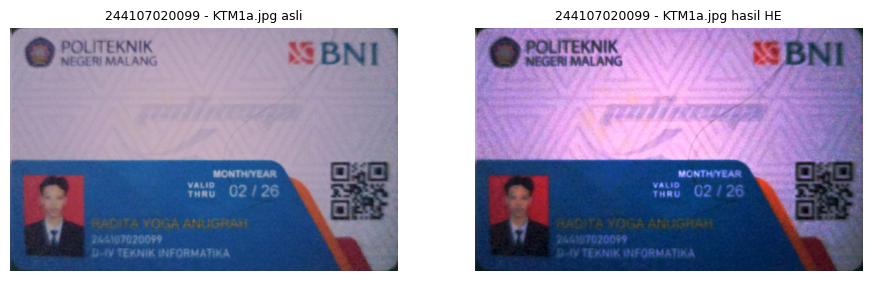

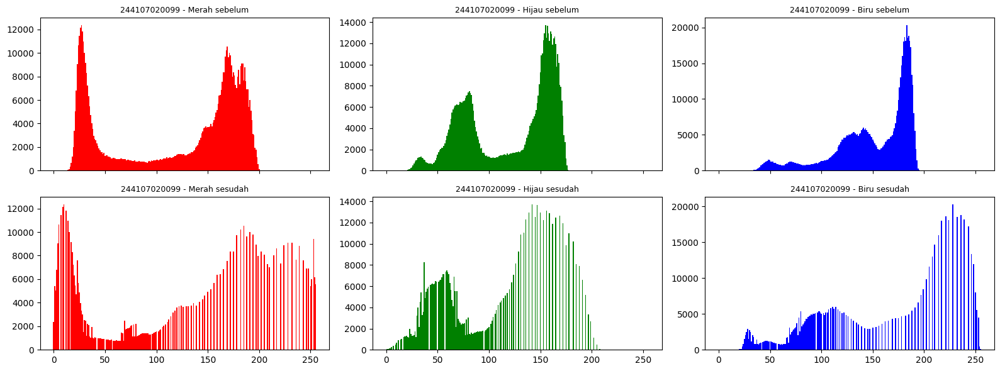

In [18]:
# TAHAP 2
ktm1a = muat(BASE + '/KTM1a.jpg')
tampil_he(ktm1a, he_warna_gabungan(ktm1a), 'KTM1a.jpg')

In [19]:
def selisih_he(bgr, tag):
    print(f'{NIM} - {tag}')
    for i, c in enumerate(['B', 'G', 'R']):
        ch  = bgr[:, :, i]
        cvh = cv.equalizeHist(ch).astype(int)
        dA  = np.abs(he_manual(ch).astype(int)    - cvh).max()
        dB  = np.abs(he_manual_cv(ch).astype(int) - cvh).max()
        print(f'  kanal {c}: selisih maks (A) rumus modul = {dA:3d} | (B) tiru OpenCV = {dB}')

selisih_he(muat(CONTOH + '/lena_lc.jpg'), 'lena_lc.jpg')
selisih_he(muat(BASE + '/KTM1a.jpg'), 'KTM1a.jpg')

244107020099 - lena_lc.jpg
  kanal B: selisih maks (A) rumus modul =   1 | (B) tiru OpenCV = 0
  kanal G: selisih maks (A) rumus modul =   0 | (B) tiru OpenCV = 0
  kanal R: selisih maks (A) rumus modul =   0 | (B) tiru OpenCV = 0
244107020099 - KTM1a.jpg
  kanal B: selisih maks (A) rumus modul =   0 | (B) tiru OpenCV = 0
  kanal G: selisih maks (A) rumus modul =   0 | (B) tiru OpenCV = 0
  kanal R: selisih maks (A) rumus modul =   0 | (B) tiru OpenCV = 0


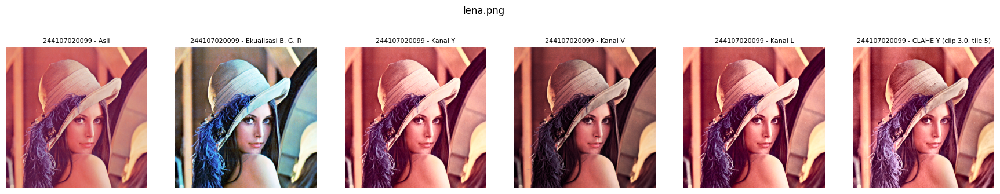

lena.png
Cara                               geser Hue (derajat)  rerata terang
Asli                                             0.00          124.0
Ekualisasi B, G, R                              74.86          128.3
Kanal Y                                          2.02          128.0
Kanal V                                          0.68           91.2
Kanal L                                          2.61          121.6
CLAHE Y (clip 3.0, tile 5)                       1.20          129.0


In [21]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d  = np.abs(h1 - h2)
    d  = np.minimum(d, 180 - d)          # Hue melingkar 0-179
    return d.mean()

def analisis_warna(bgr, tag):
    # cara 1: tiap kanal sendiri-sendiri
    kanal  = [cv.equalizeHist(k) for k in cv.split(bgr)]
    he_rgb = cv.merge(kanal)

    # cara 2: hanya kanal terang
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # cara 3 (no.4 modul): CLAHE pada kanal Y
    clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    cl_y  = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L',
             f"CLAHE Y (clip {PARAM['clip']}, tile {PARAM['tile']})"]
    citra = [bgr, he_rgb, he_y, he_v, he_l, cl_y]

    plt.figure(figsize=(22, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 6, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=8)
        plt.axis('off')
    plt.suptitle(tag)
    plt.show()

    print(tag)
    print('%-34s %18s %14s' % ('Cara', 'geser Hue (derajat)', 'rerata terang'))
    for t, c in zip(judul, citra):
        terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-34s %18.2f %14.1f' % (t, geser_hue(bgr, c) * 2, terang))   # x2: unit OpenCV -> derajat
    return judul, citra

# TAHAP 1
_ = analisis_warna(muat(CONTOH + '/lena.png'), 'lena.png')

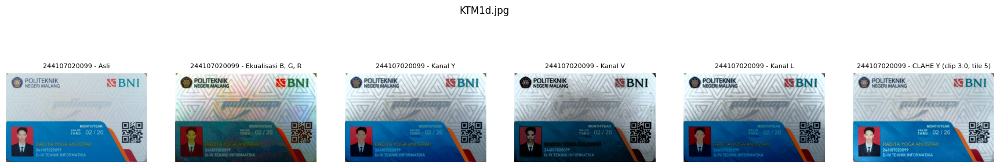

KTM1d.jpg
Cara                               geser Hue (derajat)  rerata terang
Asli                                             0.00          154.5
Ekualisasi B, G, R                              51.56          125.8
Kanal Y                                          2.75          132.5
Kanal V                                          1.66          113.8
Kanal L                                          4.11          122.4
CLAHE Y (clip 3.0, tile 5)                       0.55          151.8


In [22]:
ktm1d = muat(BASE + '/KTM1d.jpg')
judul_d, citra_d = analisis_warna(ktm1d, 'KTM1d.jpg')

Selisih maks manual vs equalizeHist : 0


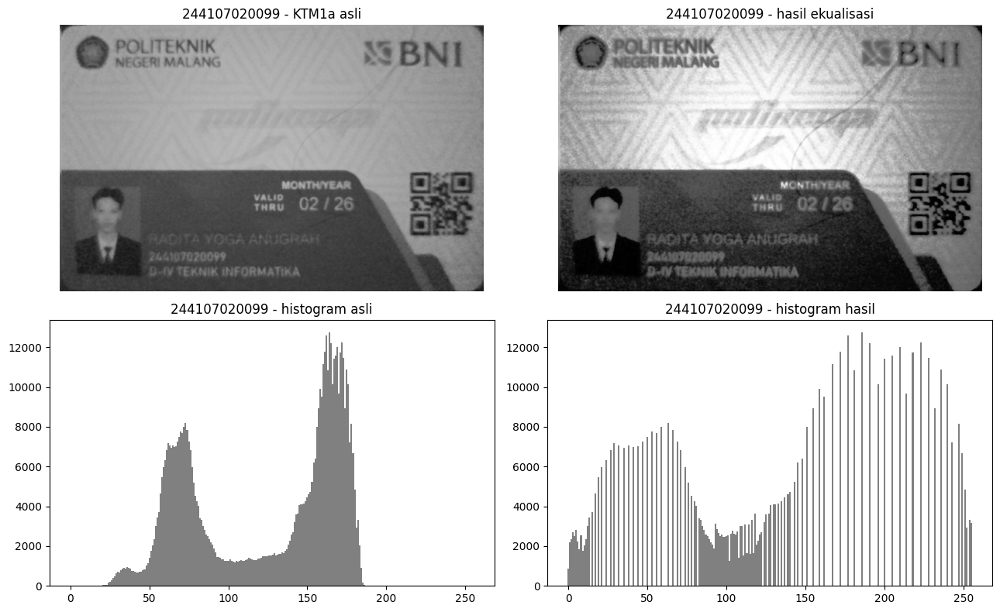

PSNR asli vs hasil ekualisasi : 18.02 dB
Kontras (std) asli -> hasil   : 46.5 -> 74.0


In [23]:
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

g      = muat(BASE + '/KTM1a.jpg', gray=True)
g_man  = he_manual_cv(g)              # manual (rumus tiru OpenCV)
g_cv   = cv.equalizeHist(g)
print('Selisih maks manual vs equalizeHist :', np.abs(g_man.astype(int) - g_cv.astype(int)).max())

fig, axs = plt.subplots(2, 2, figsize=(13, 8))
axs[0, 0].imshow(g,    cmap='gray', vmin=0, vmax=255); axs[0, 0].set_title(NIM + ' - KTM1a asli');  axs[0, 0].axis('off')
axs[0, 1].imshow(g_cv, cmap='gray', vmin=0, vmax=255); axs[0, 1].set_title(NIM + ' - hasil ekualisasi'); axs[0, 1].axis('off')
axs[1, 0].bar(range(256), np.bincount(g.ravel(),    minlength=256), color='gray', width=1.0); axs[1, 0].set_title(NIM + ' - histogram asli')
axs[1, 1].bar(range(256), np.bincount(g_cv.ravel(), minlength=256), color='gray', width=1.0); axs[1, 1].set_title(NIM + ' - histogram hasil')
plt.tight_layout(); plt.show()

print('PSNR asli vs hasil ekualisasi : %.2f dB' % psnr(g, g_cv))
print('Kontras (std) asli -> hasil   : %.1f -> %.1f' % (g.std(), g_cv.std()))

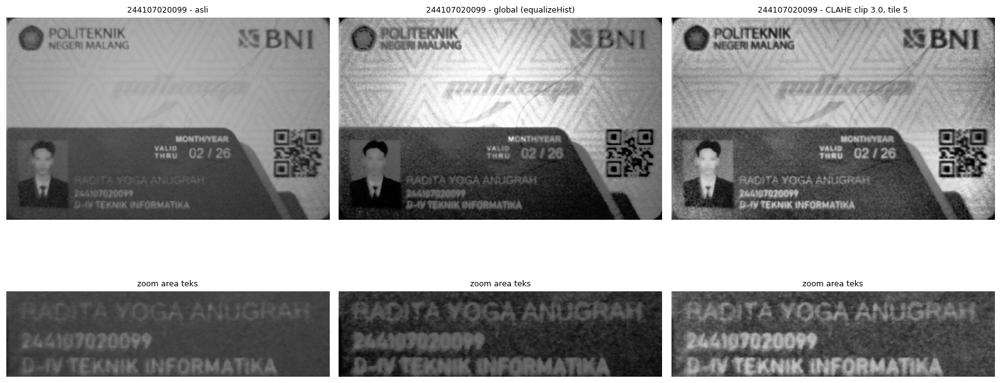

In [24]:
ROI_TEKS  = (0.76, 0.95, 0.19, 0.64)
ROI_POLOS = (0.17, 0.40, 0.05, 0.30)

def clahe_apply(g, clip, tile):
    return cv.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile)).apply(g)

# (a) CLAHE parameter pribadi vs global
g_cl = clahe_apply(g, PARAM['clip'], PARAM['tile'])
hasil = [('asli', g), ('global (equalizeHist)', g_cv),
         (f"CLAHE clip {PARAM['clip']}, tile {PARAM['tile']}", g_cl)]

fig, axs = plt.subplots(2, 3, figsize=(16, 8))
for j, (t, im) in enumerate(hasil):
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
    axs[0, j].set_title(NIM + ' - ' + t, fontsize=9); axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_TEKS), cmap='gray', vmin=0, vmax=255)
    axs[1, j].set_title('zoom area teks', fontsize=9); axs[1, j].axis('off')
plt.tight_layout(); plt.show()

clipLimit  std area polos (indikator noise)
2.0        10.21                     
3.0        12.20                     
4.0        14.26                     
6.0        18.28                     
asli       5.38                      


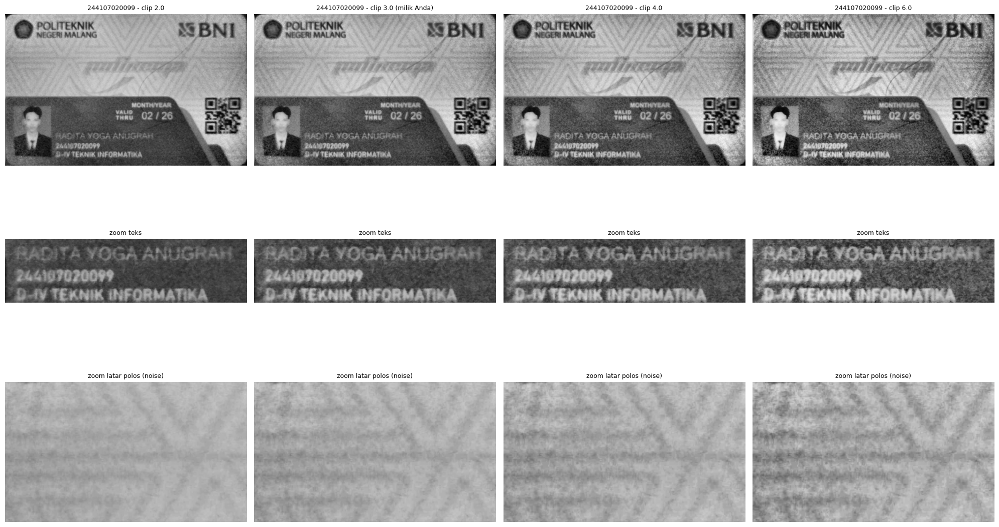

In [25]:
# (b) variasi clipLimit di sekitar nilai Anda + noise pada area polos
daftar = [2.0, 4.0, 6.0]
if PARAM['clip'] not in daftar:
    daftar = sorted(daftar + [PARAM['clip']])

fig, axs = plt.subplots(3, len(daftar), figsize=(5 * len(daftar), 12))
print('%-10s %-26s' % ('clipLimit', 'std area polos (indikator noise)'))
for j, c in enumerate(daftar):
    im = clahe_apply(g, c, PARAM['tile'])
    axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
    axs[0, j].set_title(f'{NIM} - clip {c}' + (' (milik Anda)' if c == PARAM['clip'] else ''), fontsize=9)
    axs[0, j].axis('off')
    axs[1, j].imshow(potong(im, ROI_TEKS),  cmap='gray', vmin=0, vmax=255); axs[1, j].set_title('zoom teks', fontsize=9);  axs[1, j].axis('off')
    axs[2, j].imshow(potong(im, ROI_POLOS), cmap='gray', vmin=0, vmax=255); axs[2, j].set_title('zoom latar polos (noise)', fontsize=9); axs[2, j].axis('off')
    print('%-10s %-26.2f' % (c, potong(im, ROI_POLOS).std()))
print('%-10s %-26.2f' % ('asli', potong(g, ROI_POLOS).std()))
plt.tight_layout(); plt.show()

In [28]:
def floyd_steinberg(gray, L=2):
    img  = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama  = img[y, x]
            baru  = np.round(lama / step) * step      # warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:               img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:     img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:               img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H: img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)

def floyd_steinberg_warna(bgr, L=2):
    return cv.merge([floyd_steinberg(bgr[:, :, i], L) for i in range(3)])

def sebelum_sesudah(asli, hasil, t1, t2):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    for ax, im, t in zip(axs, [asli, hasil], [t1, t2]):
        ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.set_title(NIM + ' - ' + t); ax.axis('off')
    plt.show()

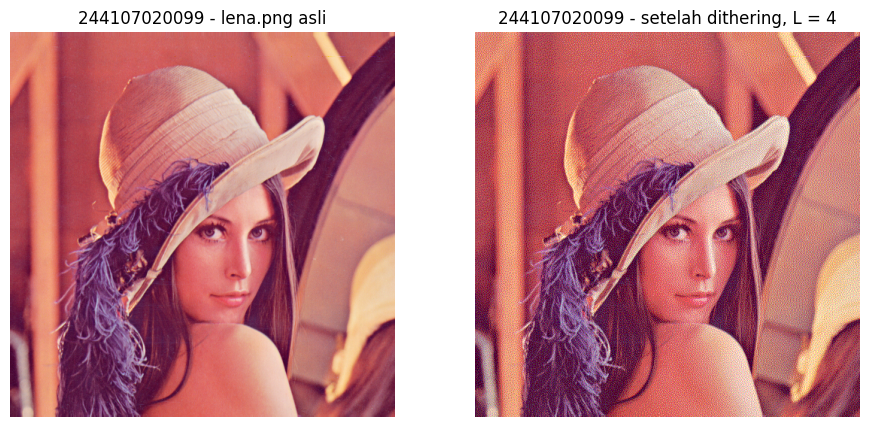

In [29]:
L_CONTOH = 4
lena_bgr = muat(CONTOH + '/lena.png')
lena_fs  = floyd_steinberg_warna(lena_bgr, L_CONTOH)

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, im, t in zip(axs, [lena_bgr, lena_fs],
                     ['lena.png asli', f'setelah dithering, L = {L_CONTOH}']):
    ax.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    ax.set_title(NIM + ' - ' + t); ax.axis('off')
plt.show()

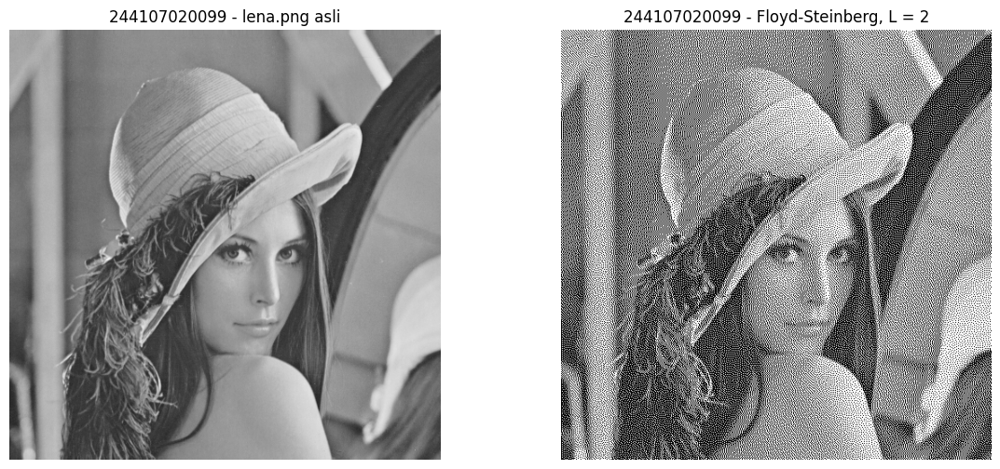

In [30]:
lena_g = muat(CONTOH + '/lena.png', gray=True)
sebelum_sesudah(lena_g, floyd_steinberg(lena_g, 2),
                'lena.png asli', 'Floyd-Steinberg, L = 2')

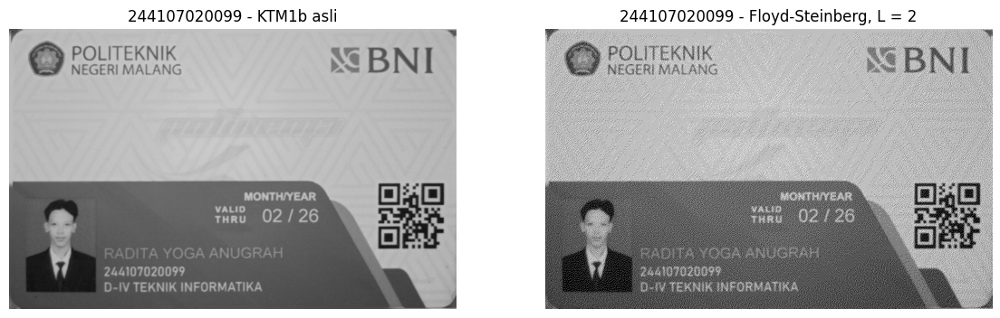

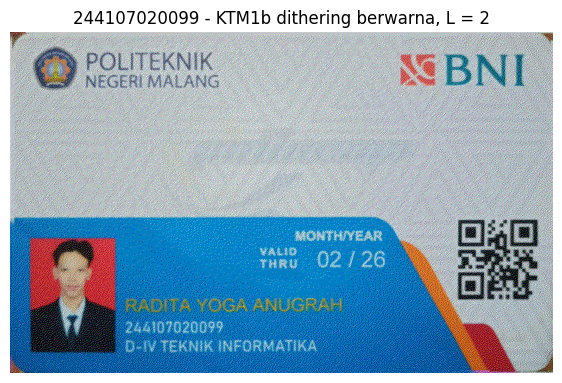

In [31]:
L = PARAM['L']
k1b = muat(BASE + '/KTM1b.jpg', gray=True)
sebelum_sesudah(k1b, floyd_steinberg(k1b, L),
                'KTM1b asli', f'Floyd-Steinberg, L = {L}')

# Opsional: versi berwarna
k1b_bgr  = muat(BASE + '/KTM1b.jpg')
fs_warna = floyd_steinberg_warna(k1b_bgr, L)
plt.figure(figsize=(7, 5))
plt.imshow(cv.cvtColor(fs_warna, cv.COLOR_BGR2RGB))
plt.title(NIM + f' - KTM1b dithering berwarna, L = {L}')
plt.axis('off'); plt.show()

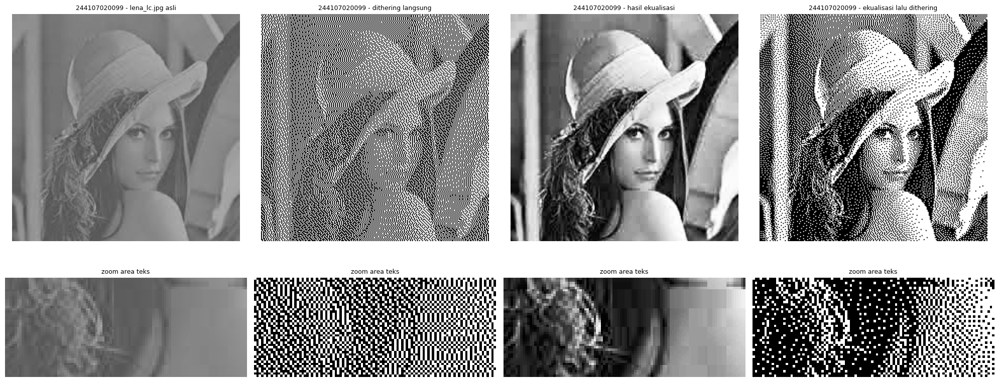

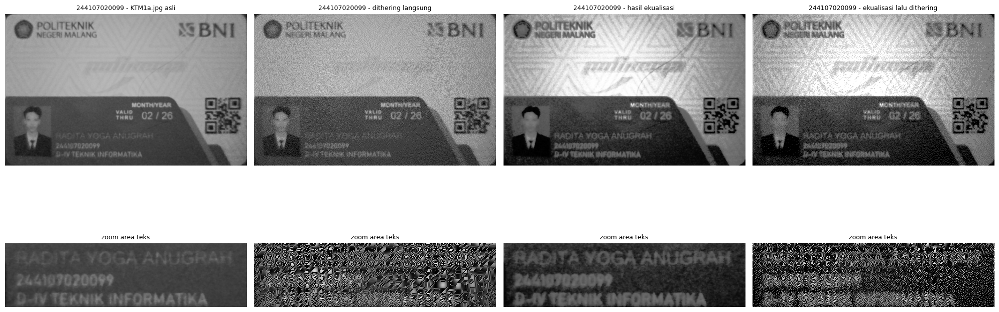

In [32]:
ROI_TEKS = (0.76, 0.95, 0.19, 0.64)

def urutan_dither(g, tag, L=2):
    langsung = floyd_steinberg(g, L)
    he       = cv.equalizeHist(g)
    he_fs    = floyd_steinberg(he, L)

    fig, axs = plt.subplots(2, 4, figsize=(20, 9))
    isi = [(g,        f'{tag} asli'),
           (langsung, 'dithering langsung'),
           (he,       'hasil ekualisasi'),
           (he_fs,    'ekualisasi lalu dithering')]
    for j, (im, t) in enumerate(isi):
        axs[0, j].imshow(im, cmap='gray', vmin=0, vmax=255)
        axs[0, j].set_title(NIM + ' - ' + t, fontsize=9); axs[0, j].axis('off')
        axs[1, j].imshow(potong(im, ROI_TEKS), cmap='gray', vmin=0, vmax=255)
        axs[1, j].set_title('zoom area teks', fontsize=9); axs[1, j].axis('off')
    plt.tight_layout(); plt.show()

# TAHAP 1 - lena_lc.jpg
urutan_dither(muat(CONTOH + '/lena_lc.jpg', gray=True), 'lena_lc.jpg')

# TAHAP 2 - KTM1a.jpg
urutan_dither(muat(BASE + '/KTM1a.jpg', gray=True), 'KTM1a.jpg')